# Pruebas Denoising
La idea de este archivo es probar el quitado de ruido para distintos espectros. Tanto el del titáneo cómo las muestras de Sulfato. Queremos comprobar el buen funcionamiento del código

## Importación de paquetes y funciones principales

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import pywt


#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)

        espectro = df['Sample'].values
        wavelength = df['Wave'].values
        return espectro[16:-16], wavelength[16:-16]
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None

# Función para quitar el ruido
from denoising_fun import  denoise_spectrum_uwt

## Archivos Titanio

In [46]:
# Ruta relativa desde Pre_Processing a los espectros
ruta_espectros = os.path.join('..', 'Spectra', '20250321_Ti_Reference_A02')

UV1 = os.path.join(ruta_espectros, 'Ti_ReferenceA02_shot1_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Ti_ReferenceA02_shot1_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Ti_ReferenceA02_shot1_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Ti_ReferenceA02_shot1_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)


#### Procesado con Sigma Clipping basado en Mediana (MAD)

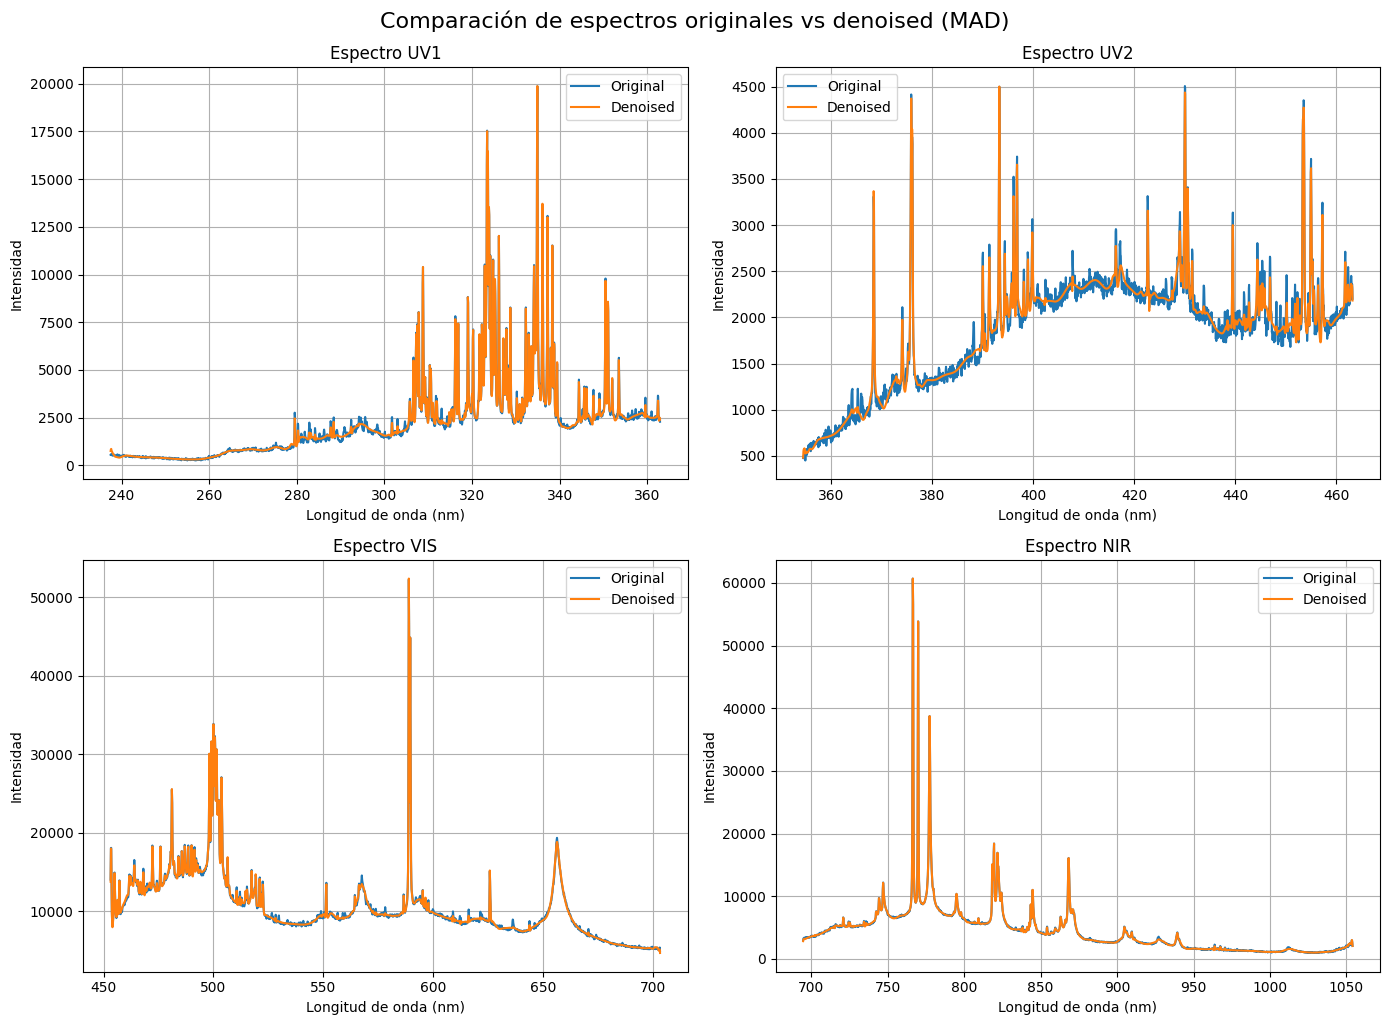

In [47]:
# Aplicar denoising a los espectros
espectro_UV1_denoised = denoise_spectrum_uwt(espectro_UV1, wavelet_name='bior3.3', threshold_sigma=3)
espectro_UV2_denoised = denoise_spectrum_uwt(espectro_UV2, wavelet_name='bior3.3', threshold_sigma=3)
espectro_VIS_denoised = denoise_spectrum_uwt(espectro_VIS, wavelet_name='bior3.3', threshold_sigma=3)
espectro_NIR_denoised = denoise_spectrum_uwt(espectro_NIR, wavelet_name='bior3.3', threshold_sigma=3)

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_denoised, espectro_UV2_denoised, espectro_VIS_denoised, espectro_NIR_denoised]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Original')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Denoised')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros originales vs denoised (MAD)", y=1.02, fontsize=16)
plt.show()

#### Procesado con Sigma Clipping iterativo tipo SuperCam

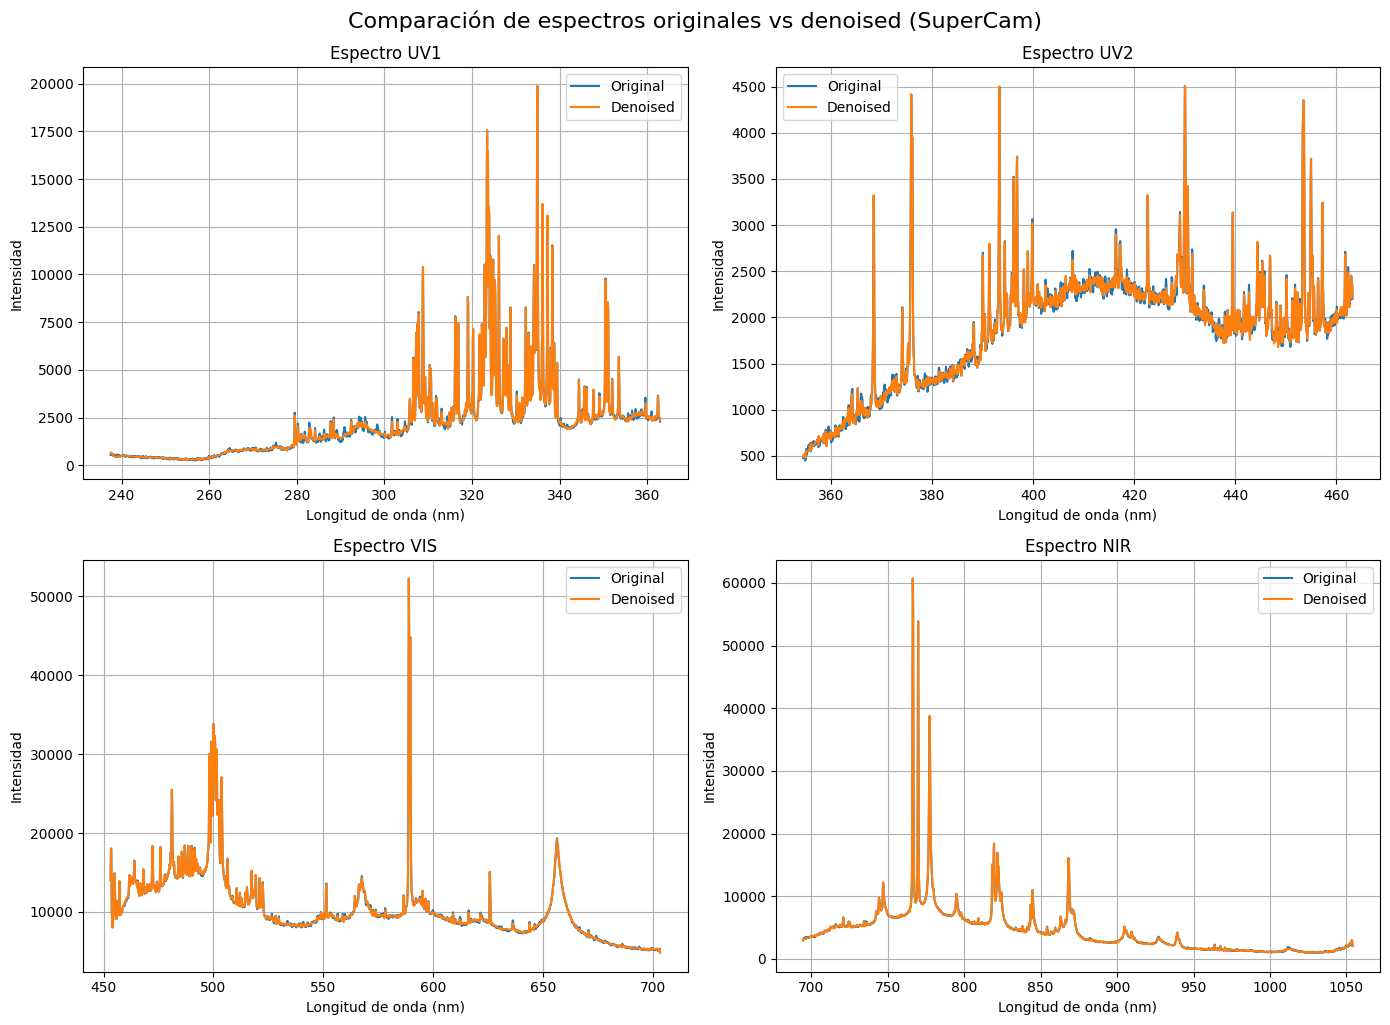

In [48]:
# Aplicar denoising a los espectros
espectro_UV1_denoised = denoise_spectrum_uwt(espectro_UV1, wavelet_name='bior3.3', threshold_sigma=3, method='supercam')
espectro_UV2_denoised = denoise_spectrum_uwt(espectro_UV2, wavelet_name='bior3.3', threshold_sigma=3, method='supercam')
espectro_VIS_denoised = denoise_spectrum_uwt(espectro_VIS, wavelet_name='bior3.3', threshold_sigma=3, method='supercam')
espectro_NIR_denoised = denoise_spectrum_uwt(espectro_NIR, wavelet_name='bior3.3', threshold_sigma=3, method='supercam')

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_denoised, espectro_UV2_denoised, espectro_VIS_denoised, espectro_NIR_denoised]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Original')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Denoised')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros originales vs denoised (SuperCam)", y=1.02, fontsize=16)
plt.show()

## Archivos Sulfato (Test 21/03/2025, Shot 1)

In [3]:
# Ruta relativa desde Pre_Processing a los espectros
ruta_espectros = os.path.join('..', 'Spectra', '20250321_First_test')

UV1 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)

#### Procesado con Sigma Clipping basado en Mediana (MAD)

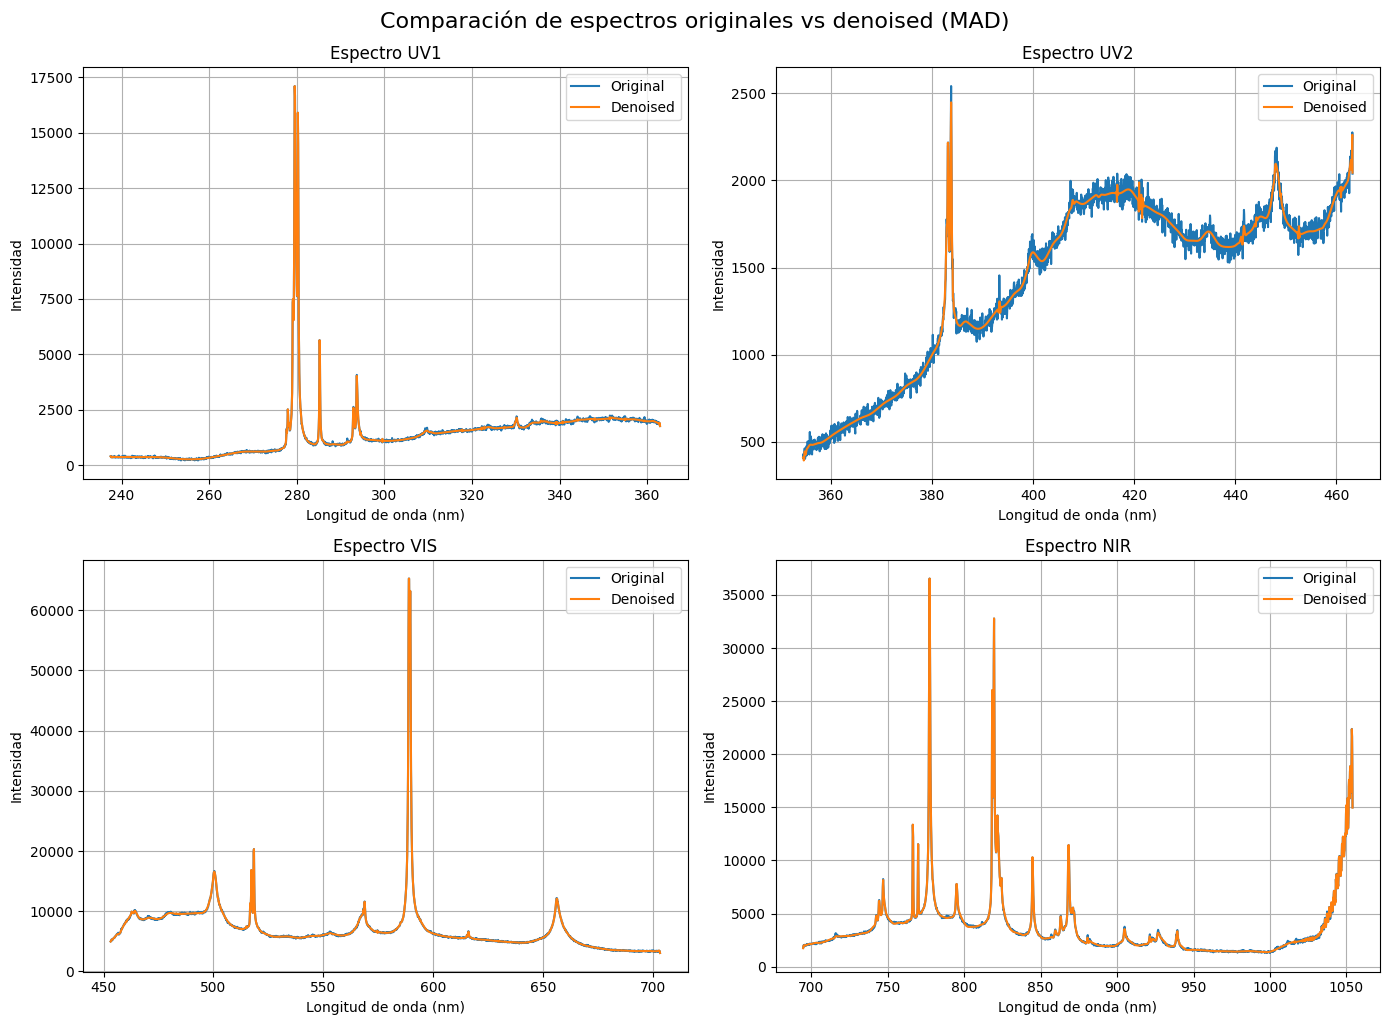

In [4]:
# Aplicar denoising a los espectros
espectro_UV1_denoised = denoise_spectrum_uwt(espectro_UV1, wavelet_name='bior3.3', threshold_sigma=3)
espectro_UV2_denoised = denoise_spectrum_uwt(espectro_UV2, wavelet_name='bior3.3', threshold_sigma=3)
espectro_VIS_denoised = denoise_spectrum_uwt(espectro_VIS, wavelet_name='bior3.3', threshold_sigma=3)
espectro_NIR_denoised = denoise_spectrum_uwt(espectro_NIR, wavelet_name='bior3.3', threshold_sigma=3)

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_denoised, espectro_UV2_denoised, espectro_VIS_denoised, espectro_NIR_denoised]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Original')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Denoised')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros originales vs denoised (MAD)", y=1.02, fontsize=16)
plt.show()

#### Procesado con Sigma Clipping iterativo tipo SuperCam

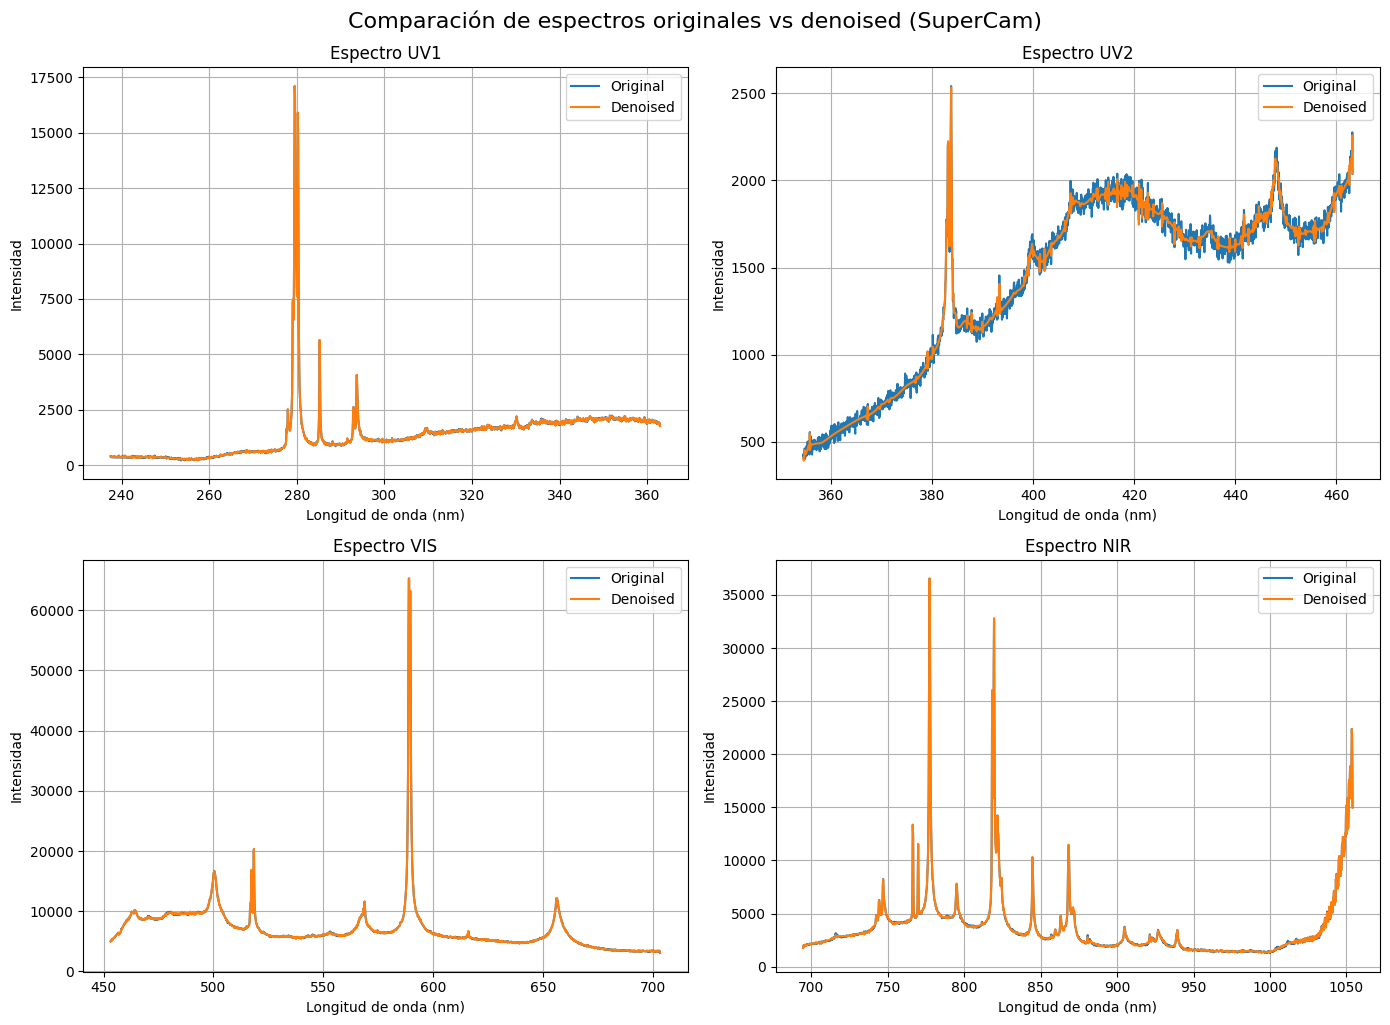

In [5]:
# Aplicar denoising a los espectros
espectro_UV1_denoised = denoise_spectrum_uwt(espectro_UV1, wavelet_name='bior3.3', threshold_sigma=3, method='supercam')
espectro_UV2_denoised = denoise_spectrum_uwt(espectro_UV2, wavelet_name='bior3.3', threshold_sigma=4, method='supercam')
espectro_VIS_denoised = denoise_spectrum_uwt(espectro_VIS, wavelet_name='bior3.3', threshold_sigma=3, method='supercam')
espectro_NIR_denoised = denoise_spectrum_uwt(espectro_NIR, wavelet_name='bior3.3', threshold_sigma=3, method='supercam')

# Visualizar espectros antes y después del denoising
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_originales = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
espectros_denoised = [espectro_UV1_denoised, espectro_UV2_denoised, espectro_VIS_denoised, espectro_NIR_denoised]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]

plt.figure(figsize=(14, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(wavelengths[i], espectros_originales[i], label='Original')
    plt.plot(wavelengths[i], espectros_denoised[i], label='Denoised')
    plt.title(f"Espectro {nombres[i]}")
    plt.xlabel("Longitud de onda (nm)")
    plt.ylabel("Intensidad")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Comparación de espectros originales vs denoised (SuperCam)", y=1.02, fontsize=16)
plt.show()